In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('Output/df_featured.csv', encoding='latin-1')
df.head()

,Restaurant ID,Restaurant Name,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,...,Rating color,Rating text,Votes,n_outlets,Is Chain,Is Rated,Is NCR,Cuisines Count,Primary Cuisine,Log_Votes
0,3400025,Jahanpanah,Agra,"E 23, Shopping Arcade, Sadar Bazaar, Agra Cant...",Agra Cantt,"Agra Cantt, Agra",78.011544,27.161661,"North Indian, Mughlai",850,...,Yellow,Good,140,1,False,True,False,2,North Indian,4.948760
1,3400341,Rangrezz Restaurant,Agra,"E-20, Shopping Arcade, Sadar Bazaar, Agra Cant...",Agra Cantt,"Agra Cantt, Agra",0.000000,0.000000,"North Indian, Mughlai",700,...,Yellow,Good,71,1,False,True,False,2,North Indian,4.276666
2,3400005,Time2Eat - Mama Chicken,Agra,"Main Market, Sadar Bazaar, Agra Cantt, Agra",Agra Cantt,"Agra Cantt, Agra",78.011608,27.160832,North Indian,500,...,Yellow,Good,94,1,False,True,False,1,North Indian,4.553877
3,3400021,Chokho Jeeman Marwari Jain Bhojanalya,Agra,"1/48, Delhi Gate, Station Road, Raja Mandi, Ci...",Civil Lines,"Civil Lines, Agra",77.998092,27.195928,Rajasthani,400,...,Green,Very Good,87,1,False,True,False,1,Rajasthani,4.477337
4,3400017,Pinch Of Spice,Agra,"23/453, Opposite Sanjay Cinema, Wazipura Road,...",Civil Lines,"Civil Lines, Agra",78.007553,27.201725,"North Indian, Chinese, Mughlai",1000,...,Green,Very Good,177,1,False,True,False,3,North Indian,5.181784


In [4]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'City', 'Address', 'Locality',
       'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Has Table booking', 'Has Online delivery',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'n_outlets', 'Is Chain', 'Is Rated', 'Is NCR',
       'Cuisines Count', 'Primary Cuisine', 'Log_Votes'],
      dtype='object')

# Univariate Analysis:

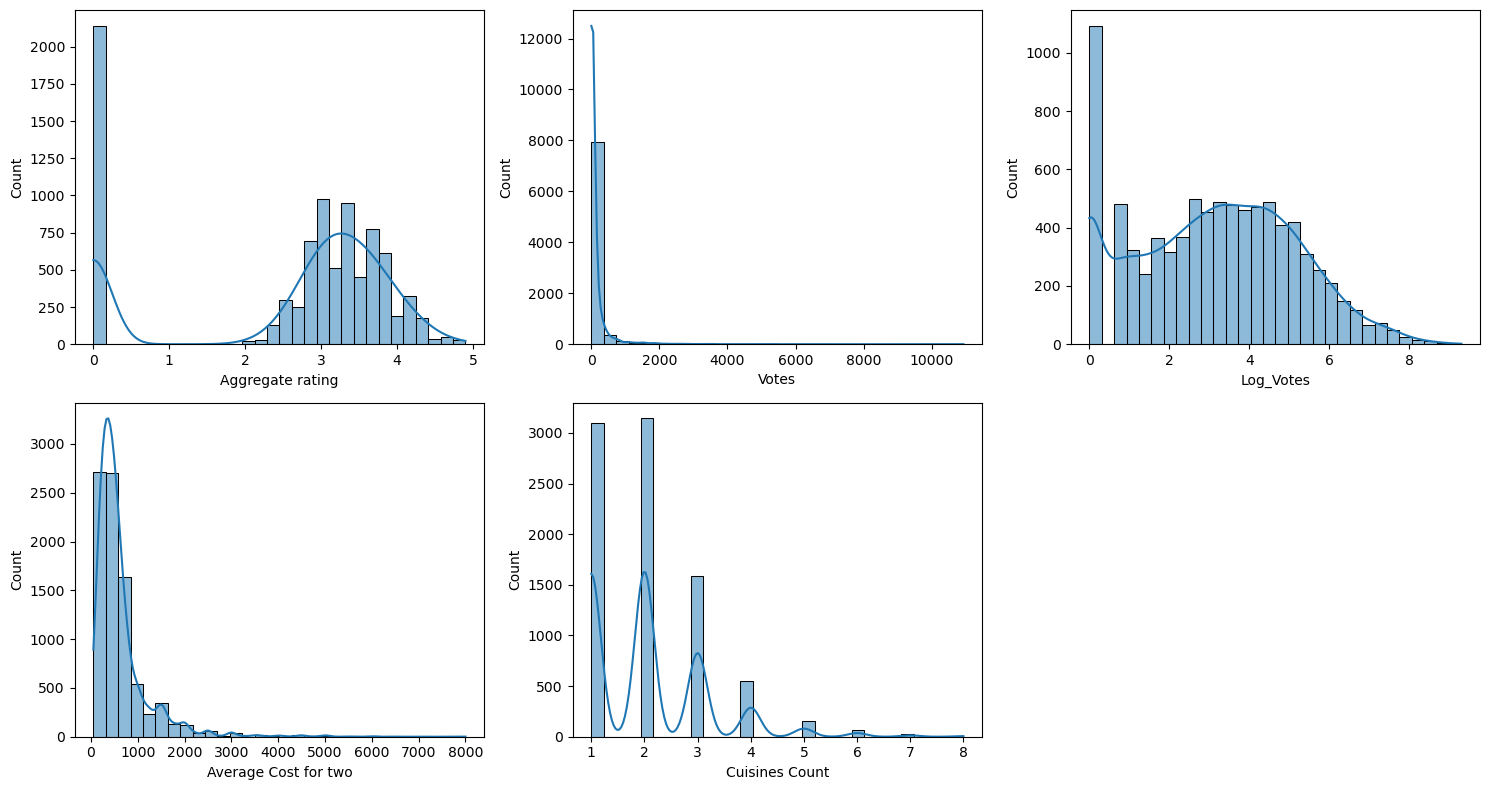

In [11]:
# Numerical columns: ['Aggreagate rating', 'Votes', 'Log_Votes', 'Average Cost for two', 'Cuisines Count']
# Ploting histogram+KDE+boxplot for the above numerical columns

numerical_columns=['Aggregate rating', 'Votes', 'Log_Votes', 'Average Cost for two', 'Cuisines Count']
fig, axes=plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
for i, cols in enumerate(numerical_columns):
    row=i//3
    c=i%3
    sns.histplot(df[cols], kde=True, ax=axes[row][c], bins=30)
    plt.title(cols)
fig.delaxes(ax=axes[1][2])
plt.tight_layout()
plt.show()
    

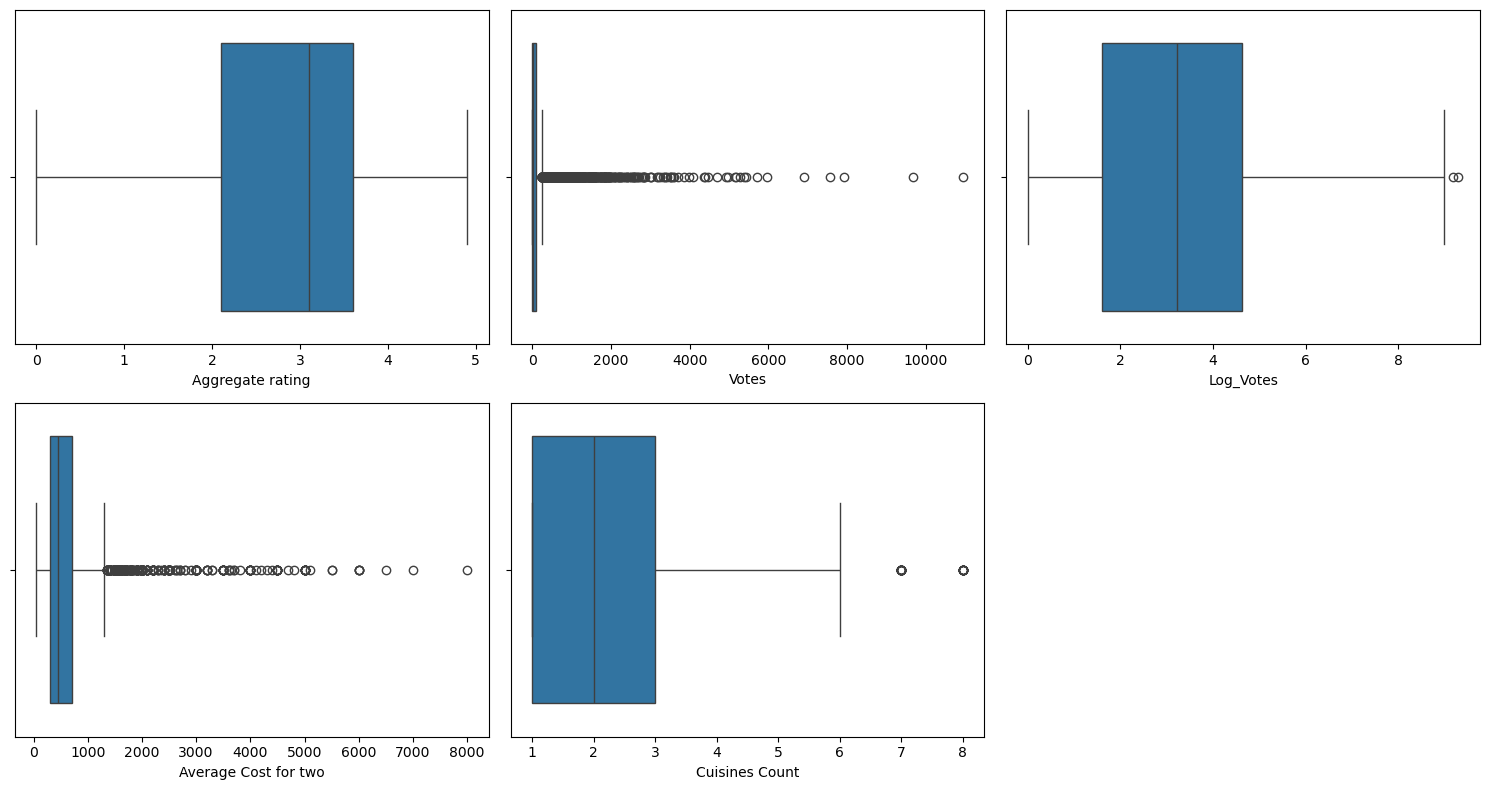

In [17]:
#boxplot:
fig, axes_box=plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
for i, cols in enumerate(numerical_columns):
    row=i//3
    col=i%3
    sns.boxplot(x=df[cols], ax=axes_box[row][col])
    plt.title(cols)

fig.delaxes(ax=axes_box[1][2])
plt.tight_layout()
plt.show()

### Observation:
- **Aggregate rating** is bimodal, not simply skewed: 2,139 rows (24.7%) sit at exactly 0 (mean 2.52 vs median 3.10, skew -0.88), which is the *"Not rated"* flag encoded as a number (`Rating text == "Not rated"`), not restaurants that were genuinely rated poorly. Once separated by `Is Rated`, the real rating cluster is roughly bell-shaped between ~2.5-4.5. IQR flags 0 outliers here only because both populations sit inside the bounded 0-4.9 rating scale.
- **Votes** is extremely right-skewed (skew 9.65, kurtosis 144.9) - mean (137.3) is far above median (24.0), pulled up by a small number of viral restaurants with thousands of votes. IQR flags 12.1% of rows (1,048) as outliers, which mostly reflects that IQR fences don't suit this shape of data rather than 1,048 genuine anomalies.
- **Log_Votes** confirms the `log1p` transform worked: skew drops from 9.65 to 0.07 (near-symmetric), kurtosis flattens from 144.9 to -0.77, and IQR outliers collapse from 1,048 to 2. Use this column for correlation/modeling instead of raw `Votes`.
- **Average Cost for two** is right-skewed (skew 3.59, kurtosis 20.4) with 813 IQR outliers (9.4%) - matches the premium-restaurant segment already investigated in `Data_cleaning.ipynb` and deliberately **kept** (Delhi NCR fine dining, higher avg rating).
- **Cuisines Count** is close to well-behaved: mild right skew (1.34), most restaurants offer 1-3 cuisines (median 2), only 38 IQR outliers (0.4%).
- **Action item:** from here on, any analysis involving `Aggregate rating` must run on `df[df["Is Rated"]]`, not the full `df` - otherwise the 24.7% "not rated" spike will contaminate every correlation and comparison.

In [18]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'City', 'Address', 'Locality',
       'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Has Table booking', 'Has Online delivery',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'n_outlets', 'Is Chain', 'Is Rated', 'Is NCR',
       'Cuisines Count', 'Primary Cuisine', 'Log_Votes'],
      dtype='object')

In [20]:
# Categorical columns: ['Price Range', 'Has Table booking', 'Has Online delivery', 'is Chain', 'Primary Cuisine', 'Is NCR']
# Grouping the catogorical columns according to their types:
binary_ordinal_columns=['Has Table booking', 'Has Online delivery', 'Is Chain', 'Is NCR', 'Is Rated', 'Price range']
high_cardinality_columns=['Primary Cuisine', 'City', 'Locality']

#Frequency+Proportion for the binary/ordinal columns
for cols in binary_ordinal_columns:
    counts=df[cols].value_counts().sort_index()
    percentages=(df[cols].value_counts(normalize=True).sort_index()*100).round(2)
    summary=pd.DataFrame({'count':counts, 'percentage':percentages})
    print(f"---{cols}---")
    print(summary)
    print()

---Has Table booking---
                   count  percentage
Has Table booking                   
0                   7532       87.15
1                   1111       12.85

---Has Online delivery---
                     count  percentage
Has Online delivery                   
0                     6220       71.97
1                     2423       28.03

---Is Chain---
          count  percentage
Is Chain                   
False      5888       68.12
True       2755       31.88

---Is NCR---
        count  percentage
Is NCR                   
False     696        8.05
True     7947       91.95

---Is Rated---
          count  percentage
Is Rated                   
False      2139       24.75
True       6504       75.25

---Price range---
             count  percentage
Price range                   
1             4286       49.59
2             2858       33.07
3             1111       12.85
4              388        4.49



In [24]:
# Cardinality and cumulative coverage for high cardinality columns
# For high cardinality columns: check the total cardinality, top-N coverage, and the long tail
for cols in high_cardinality_columns:
    freq=(df[cols].value_counts(normalize=True)*100).round(2)
    cummulative=freq.cumsum()
    rare_counts=(df[cols].value_counts()<10).sum()

    print(f"---{cols}---")
    print(f"Unique Categories: {df[cols].nunique()}")
    print(f"Top 15 categories cover: {cummulative.iloc[14]:.2f}% of rows")
    print(f"Catogories with less than 10 rows: {rare_counts} of {df[cols].nunique()}")

---Primary Cuisine---
Unique Categories: 74
Top 15 categories cover: 88.59% of rows
Catogories with less than 10 rows: 37 of 74
---City---
Unique Categories: 43
Top 15 categories cover: 94.30% of rows
Catogories with less than 10 rows: 3 of 43
---Locality---
Unique Categories: 783
Top 15 categories cover: 14.66% of rows
Catogories with less than 10 rows: 589 of 783


### Observation:
- **Binary/ordinal columns:** `Has Table booking` (87.15% No) and `Has Online delivery` (71.97% No) are both imbalanced minority features; `Is Chain` (31.88% chain) is a substantial, trustworthy segment. `Is NCR` (91.95% NCR) and `Is Rated` (75.25% rated) both match numbers already established earlier in the project - a working sanity check, not a coincidence.
- **`Price range`** shows a clean monotonic decline across tiers (49.59% -> 33.07% -> 12.85% -> 4.49%) - the market is dominated by budget dining, and each step up in price tier holds a shrinking share.
- **`Primary Cuisine` (74 categories) and `City` (43 categories) are concentrated:** their top 15 categories cover 88.59% and 94.30% of rows respectively, so a "top 15 + Other" chart will represent them honestly.
- **`Locality` (783 categories) is fragmented, not concentrated:** its top 15 cover only 14.66% of rows, and 589 of 783 localities (75%) have fewer than 10 rows. A top-N chart here would misleadingly claim to summarize the column while representing a small slice of it - `Locality` needs a minimum-row filter (plan.md suggests >=30) rather than a top-N plot, and any groupby statistic on raw `Locality` should be treated as unreliable for the long tail.
- **Action item:** use `City`/`Is NCR` for geography in charts and comparisons; reserve `Locality` for filtered, fine-grained analysis only (>=30 rows per locality), not for a general countplot.